# Introduction to port-Hamiltonian-systems - Building a pH system in $\texttt{Julia}$

This notebook gives an overview of the implementation and some example usages. In this library, we differ between two types of port-Hamiltonian systems (structs). To use the implementation you need to load the package as follows:

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

using TestPhsSolver

  Activating project at `c:\Users\horro\Git\manus-phs-solver`

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## 1. port-Hamiltonian ODE systems

The first one is for linear port-Hamiltonian ODE systems given by

$$
\dot{x} = (J - R)\cdot \nabla\mathcal{H}(x) + Gu,\quad y=G^T\cdot\nabla\mathcal{H}(x)
$$

where $\nabla\mathcal{H}(x) = Q\cdot x$ for some matrix $Q$. This $Q$ is thus defined by the underlying quadratic Hamiltonian $\mathcal{H}(x) = \frac{1}{2}x^T Qx$.

The struct $\texttt{pHSystem}$ needs

1. An interconnection matrix $\texttt{J}$ that is skew symmetric
2. A dissipation matrix $\texttt{R}$ that is positive semidefinite (p.s.d.)
3. The matrix $Q$ ($\texttt{Qe}$) for the linear relation between state and gradient of the Hamiltonian
4. The input/output matrix $\texttt{G}$

It will auto-detect the size of the system and have the size-property saved as $\texttt{n}$. Example:

$$
\texttt{sys} = \texttt{pHSystem}(\texttt{J}, \texttt{R}, \texttt{Qe}, \texttt{G})
$$

$\texttt{sys}$ now has an additional automatically generated property $\texttt{sys}.\texttt{n}$ corresponding to the size of the matrix $\texttt{Qe}$ (or others). This also means that this struct can not handle any differential algebraic equations in the pH formulation but only ordinary differential equations. If you are interested in also including DAEs, skip to the next section.


### Example: Mass-Spring-Damper with external force

We consider a two-dimensional port-Hamiltonian ODE system with state $x = [q, p]^T$ with displacement $q$ and momentum $p$. The Hamiltonian is given by

$$
\mathcal{H}(x) = \frac{1}{2}kq^2 + \frac{1}{2m}p^2 \stackrel{!}{=} \frac{1}{2}x^T Q x,
$$

i.e. $\texttt{Qe} = \mathrm{diag}(k, 1/m)$. The interconnection, dissipation and input/output matrices are given by

$$
J = \left[\begin{matrix}
0 & 1\\
-1 & 0
\end{matrix}\right],\quad R = \left[\begin{matrix}
0 & 0\\
0 & d
\end{matrix}\right], G = \left[\begin{matrix}
0\\
1
\end{matrix}\right].
$$

The input can be chosen arbitrary, we will use $u(t) = \sin(t)$. The initial value of the system will be 

$$
x(0) = \left[\begin{matrix}
q(0)\\
p(0)
\end{matrix}\right] = \left[\begin{matrix}
1\\
-4
\end{matrix}\right]
$$

Let's initialize the $\texttt{pHSystem}$ by using its config file (2D_MSD_System.jl) with the matrices above.


In [2]:
cfg_MSD = include("./examples/Mass Spring Damper 2D System/config/2D_MSD_System.jl")

# System struct only needs defining matrices J, R, Qe, G
sys_MSD = pHSystem(cfg_MSD.J, cfg_MSD.R, cfg_MSD.Qe, cfg_MSD.G);

When initialized, we can use the corresponding simulator $\texttt{Simulator}$ and its function $\texttt{simulate}$ to approximate the underlying dynamics on a time interval $[0, T]$ for time terminal time $T>0$. For this example, we will use the currently only implemented method for pHODE systems (:Euler) and a step size of $\texttt{dt}=0.002$ on a 20 seconds interval, i.e. $T=20$.

In [3]:
# Simulator struct only needs pHSystem, timestep-size, simulation method
sim_MSD = Simulator(sys_MSD, cfg_MSD.dt, cfg_MSD.method)

# Simulation itself needs the simulator struct, initial condition of system, input/control u, and time interval
t, states, output = simulate(sim_MSD, cfg_MSD.x0, cfg_MSD.u, cfg_MSD.tspan);

We can use utility functions for visualizing the results.

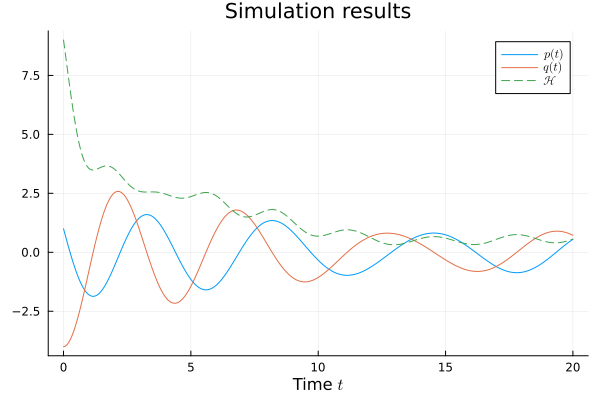

In [4]:
using LaTeXStrings

#p1 = plot_energy(t, states, sys_MSD)
#p2 = plot_states(t, states)
p3 = plot_results(t, states; sys=sys_MSD, separate=false, state_labels=[L"$p(t)$", L"$q(t)$"])

## 2. port-Hamiltonian DAE systems

For linear port-Hamiltonian DAE systems given by

$$
E\dot{x} = (J - R)\texttt{Qe}x + Gu,\quad y=G^Tx,
$$

we can use the struct $\texttt{pHDescriptorSystem}$, that needs

1. An interconnection matrix $J$ that is skew symmetric
2. A dissipation matrix $R$ that is positive semidefinite (p.s.d.)
3. The input/output matrix $G$
4. The matrix $E$ that can be singular.
5. $\texttt{QH}$ is an optional input for the Hamiltonian quadratic form matrix, i.e. $H(x) = 0.5*x^T \texttt{QH} * x$. This will be computed automatically from $E$ if not given explicitly.
6. Optionally, one can vary the matrix $\texttt{Qe}$ as well, in the usual case we have for pHDAEs $\texttt{Qe} = I$. This is tested for consistency with $E$ in DAE formulation.

It will autodetect the size of the system and have the size-property $\texttt{n}, \texttt{m}$ saved. We will use the example of a DC generator from [1] as an example of the modelling and solver. Any valid port-Hamiltonian model can be used. Similar to the previous example, we will now consider an example that was used for the implementation to verify its viability.

In contrast to $\texttt{pHSystem}$, the struct $\texttt{pHDescriptorSystem}$ also needs a specification of the domain investigated, meaning that we need to specify, if we are considering the energy variables of the system or co-energy-variables. This means that, we are either in one of two cases:

1. Energy-states (rep=:x_state): We expect $\texttt{Qe} = \texttt{QH}$, the states are flux/charges (!)

2. Co-energy-states (rep=:z_state): We expect $\texttt{Qe} = I$, the states are voltages/currents (!)



### Example: DC power network

We are considering the following port-Hamiltonian differential algebraic equation system specified by the following matrices:

$$
E = \mathrm{diag}(L, C_1, C_2, 0.0, 0.0),\quad J = \left[\begin{matrix}
0.0 & -1.0 &  1.0  & 0.0  & 0.0\\
1.0 & 0.0 & 0.0 & -1.0 & 0.0\\
-1.0 & 0.0 & 0.0 & 0.0 & -1.0\\
0.0 & 1.0 & 0.0 & 0.0 & 0.0\\
0.0 & 0.0 & 1.0 & 0.0 & 0.0
\end{matrix}\right],\quad R = \mathrm{diag}(R_L, 0.0, 0.0, R_G, R_R)
$$

as well as

$$
G = \left[\begin{matrix}
0.0\\
0.0\\
0.0\\
1.0\\
0.0
\end{matrix}\right],\quad \texttt{Qe} = I_5,\quad \texttt{QH} = \mathrm{diag}(L, C_1, C_2, 0, 0).
$$

In [5]:
cfg_DCGen = include("./examples/Mehrmann_2019_DC_Generator/config/DC_Generator_Mehrmann.jl")

# System struct only needs defining matrices E, J, R, Q = Identity, G
sys_DCGen = pHDescriptorSystem(cfg_DCGen.E, cfg_DCGen.J, cfg_DCGen.R, cfg_DCGen.Qe, cfg_DCGen.G; QH=cfg_DCGen.QH, rep=:z_state);

In [6]:
# Simulator struct only needs pHDescriptorSystem, timestep-size, simulation method
sim_DCGen =  DescriptorSimulator(sys_DCGen, cfg_DCGen.dt, cfg_DCGen.method)

# Simulation itself needs the simulator struct, initial condition of system, input/control u, and time interval
t, states, output = simulate(sim_DCGen, cfg_DCGen.x0_nocontrol, cfg_DCGen.u_nocontrol, cfg_DCGen.tspan);

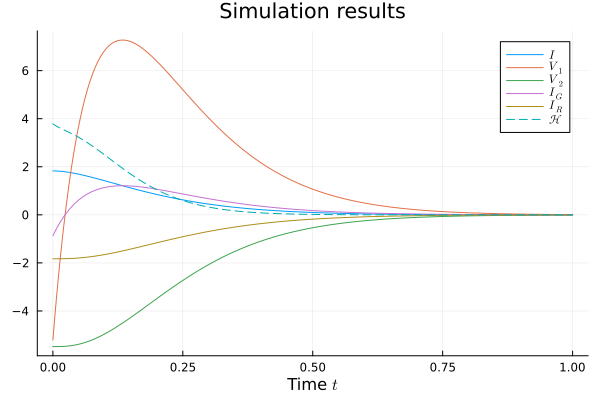

In [7]:
using LaTeXStrings
#p1 = plot_energy(t, states, sys_DCGen)
#p2 = plot_states(t, states)
p3 = plot_results(t, states; sys=sys_DCGen, state_labels=[L"$I$", L"$V_1$", L"$V_2$", L"$I_G$", L"$I_R$"], separate=false)